## (A) 🧮 Optional: En enda neuron

- I denna förberedande uppgift ska inte någon fungerande OCR-mjukvara tas fram. Fokus är endast på att förstå hur en enda neuron skulle kunna implementeras, utan färdiga AI-libraries.
- A1: Neuron-implementation: Implementera en Neuron-klass utan Numpy, med bara vanliga räknesätten (`+ - * /`).
- A2: Neuron-implementation: NumPy vektor-multiplikation internt i varje Neuron-objekt.

In [2]:
import random
_e = 2.718281828459045
class Neuron:

    ACTIVATION_FUNCS = {
        'sigmoid':    lambda z: 1.0 / (1.0 + _e ** (-z)),
        'relu':       lambda z: max(0.0, z),
        'leaky_relu': lambda z: z if z > 0 else 0.01 * z,
    }

    def __init__(self, n_inputs: int, activation: str = 'sigmoid'):
        if activation not in self.ACTIVATION_FUNCS:
            raise ValueError(f"Okänd aktivitetsfunktion: {activation}")

        random.seed(42)
        self.weights = [random.gauss(0, 0.1) for _ in range(n_inputs)]
        self.bias    = 0.5
        self.activation = activation

    def _activate(self, z: float) -> float:
        return self.ACTIVATION_FUNCS[self.activation](z)

    def forward(self, inputs: list) -> float:
        if len(inputs) != len(self.weights):
            raise ValueError("Antal inputs matchar inte antal vikter.")

        z = self.bias
        for w, x in zip(self.weights, inputs):
            z += w * x

        return self._activate(z)

test_input = [1.0, 0.5, -1.0]

neuron_sig = Neuron(n_inputs=len(test_input), activation='sigmoid')
neuron_relu = Neuron(n_inputs=len(test_input), activation='relu')
neuron_leaky = Neuron(n_inputs=len(test_input), activation='leaky_relu')

output_sig = neuron_sig.forward(test_input)
print(f"Sigmoid — Neuron output: {output_sig:.6f}")
print(f"          Vikter: {[f'{w:.4f}' for w in neuron_sig.weights]}")
print(f"          Bias:   {neuron_sig.bias}")

print()
print("##" * 25)
output_relu = neuron_relu.forward(test_input)
print(f"RELU — NeuronPure output: {output_relu:.6f}")
print(f"       Vikter: {[f'{w:.4f}' for w in neuron_relu.weights]}")
print(f"       Bias:   {neuron_relu.bias}")

print()
print("##" * 25)
output_leaky = neuron_leaky.forward(test_input)
print(f"Leaky — NeuronPure output: {output_leaky:.6f}")
print(f"        Vikter: {[f'{w:.4f}' for w in neuron_leaky.weights]}")
print(f"        Bias:   {neuron_leaky.bias}")

Sigmoid — Neuron output: 0.619653
          Vikter: ['-0.0144', '-0.0173', '-0.0111']
          Bias:   0.5

##################################################
RELU — NeuronPure output: 0.488077
       Vikter: ['-0.0144', '-0.0173', '-0.0111']
       Bias:   0.5

##################################################
Leaky — NeuronPure output: 0.488077
        Vikter: ['-0.0144', '-0.0173', '-0.0111']
        Bias:   0.5


## (B) ✅ ANN-lager: NumPy version

Att vi nu ska implementera ett helt neuron-lager betyder att vi nu inte längre behöver någon separat Neuron-klass, eftersom vi kommer beräkna output från samtliga neuroner i lagret som en enda stor matris-operation:

- Alla input till ett lager = NumPy-vektor
- Alla vikter för alla neuroner i ett lager = en NumPy-matris
- Observera att vi inte kommer att träna nätverket som är implementerat som en NumPy-beräkning - eftersom det blir mycket enklare i (C) när vi övergår till PyTorch.

In [3]:
import numpy as np

class NeuronNp:
    ACTIVATION_FUNCS = {
        'sigmoid':    lambda z: 1.0 / (1.0 + np.exp(-z)),
        'relu':       lambda z: np.maximum(0, z),
        'leaky_relu': lambda z: z if z > 0 else 0.01 * z,
        'tanh':       np.tanh,
    }

    def __init__(self, n_inputs: int, activation: str = 'sigmoid'):
        rng = np.random.default_rng(seed=42)
        self.weights    = rng.normal(0, 0.1, size=(n_inputs,))
        self.bias       = 0.5
        self.activation = activation

    def _activate(self, z: float) -> float:
        return self.ACTIVATION_FUNCS[self.activation](z)

    def forward(self, inputs: list) -> float:
        inputs = np.asarray(inputs, dtype=np.float64)
        z = np.dot(self.weights, inputs) + self.bias   # weights · inputs + bias
        return self._activate(z)


NeuronNp(n_inputs=len(test_input)).forward(test_input)


np.float64(0.5995108464871307)

In [4]:
import numpy as np

class DenseLayer:
    ACTIVATION_FUNCS = {
        'sigmoid':    lambda z: 1.0 / (1.0 + np.exp(-z)),
        'relu':       lambda z: np.maximum(0, z),
        'leaky_relu': lambda z: np.where(z > 0, z, 0.01 * z),
        'tanh':       np.tanh,
    }

    def __init__(self, n_inputs, n_neurons, activation='sigmoid'):
        rng = np.random.default_rng(seed=42)
        self.weights = rng.normal(0, 0.1, size=(n_neurons, n_inputs))
        self.biases  = np.zeros(n_neurons)
        self.activation = activation

    def forward(self, inputs):
        inputs = np.asarray(inputs, dtype=np.float64)
        z = self.weights @ inputs + self.biases
        return self.ACTIVATION_FUNCS[self.activation](z)

test_input = [1.0, 0.5, -1.0]
layer = DenseLayer(n_inputs=3, n_neurons=4, activation='sigmoid')

print(f"Input:          {test_input}")
print(f"Viktmatris shape: {layer.weights.shape}  (n_neurons × n_inputs)")
print(f"Viktmatris:\n{layer.weights}\n")
print(f"Bias-vektor:    {layer.biases}")
print(f"Output (4 neuroner): {layer.forward(test_input)}")

Input:          [1.0, 0.5, -1.0]
Viktmatris shape: (4, 3)  (n_neurons × n_inputs)
Viktmatris:
[[ 0.03047171 -0.10399841  0.07504512]
 [ 0.09405647 -0.19510352 -0.13021795]
 [ 0.01278404 -0.03162426 -0.00168012]
 [-0.08530439  0.0879398   0.07777919]]

Bias-vektor:    [0. 0. 0. 0.]
Output (4 neuroner): [0.47587559 0.53163834 0.49966301 0.47025674]


In [5]:
layer1 = DenseLayer(784, 128, activation='relu')
layer2 = DenseLayer(128, 64,  activation='relu')
layer3 = DenseLayer(64,  10,  activation='sigmoid')

x = np.random.randn(784)

h1  = layer1.forward(x)
h2  = layer2.forward(h1)
out = layer3.forward(h2)

print("Flerlagernätverk: 784 → 128 → 64 → 10")
print(f"  Layer 1  vikter: {layer1.weights.shape}  →  output: {h1.shape}")
print(f"  Layer 2  vikter: {layer2.weights.shape}  →  output: {h2.shape}")
print(f"  Layer 3  vikter: {layer3.weights.shape}  →  output: {out.shape}")
print(f"\nSlutresultat (10 klasser): {np.round(out, 4)}")

Flerlagernätverk: 784 → 128 → 64 → 10
  Layer 1  vikter: (128, 784)  →  output: (128,)
  Layer 2  vikter: (64, 128)  →  output: (64,)
  Layer 3  vikter: (10, 64)  →  output: (10,)

Slutresultat (10 klasser): [0.6302 0.2775 0.6732 0.7746 0.366  0.6174 0.4831 0.4254 0.5323 0.2109]


## (C) ✅ ANN-lager: PyTorch version:

- Använd PyTorch 2.1 (eller bättre). Använd helst Python 3.10 (eller bättre).
- Kopplas först ihop alla lager i perceptronen så att du får en PyTorch-modell (a.k.a. module). Denna definierar i detalj compute-grafen för din perceptron.
- Använd därefter din perceptron via PyTorch. Googla själv för att få information om hur detta går till rent praktiskt. Det finns gott om information på webben kring PyTorch!
- I denna version ska även träning av nätverket ske, d.v.s. vi ska loopa över epochs, och applicera back-prop. En vidareutveckling av back-prop som kallas ADAM brukar användas eftersom den är både snabb och inte lika ofta fastnar i dåliga lokala minima, jämfört med ren back-prop.
- Se avsnittet “Tips för (C)” nedan.

In [6]:
!pip install torch torchvision --quiet

## Ladda ner MNIST dataset

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

batch_size = 64
learning_rate = 0.001
epochs = 16

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cpu")
print(f"Använder: {device}")



100%|██████████| 9.91M/9.91M [00:00<00:00, 10.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 303kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.8MB/s]

Använder: cpu


In [8]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


In [9]:
model = SimpleNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epoch_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/16, Loss: 0.2747
Epoch 2/16, Loss: 0.1158
Epoch 3/16, Loss: 0.0829
Epoch 4/16, Loss: 0.0655
Epoch 5/16, Loss: 0.0520
Epoch 6/16, Loss: 0.0421
Epoch 7/16, Loss: 0.0371
Epoch 8/16, Loss: 0.0312
Epoch 9/16, Loss: 0.0284
Epoch 10/16, Loss: 0.0235
Epoch 11/16, Loss: 0.0240
Epoch 12/16, Loss: 0.0198
Epoch 13/16, Loss: 0.0182
Epoch 14/16, Loss: 0.0165
Epoch 15/16, Loss: 0.0177
Epoch 16/16, Loss: 0.0124


In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        outputs = model(data)
        predicted = outputs.argmax(dim=1)

        total += target.size(0)
        correct += (predicted == target).sum().item()

final_acc  = 100 * correct / total
print(f"Accuracy på testdata: {final_acc :.2f}%")

Accuracy på testdata: 97.66%


# Visualisera körningen

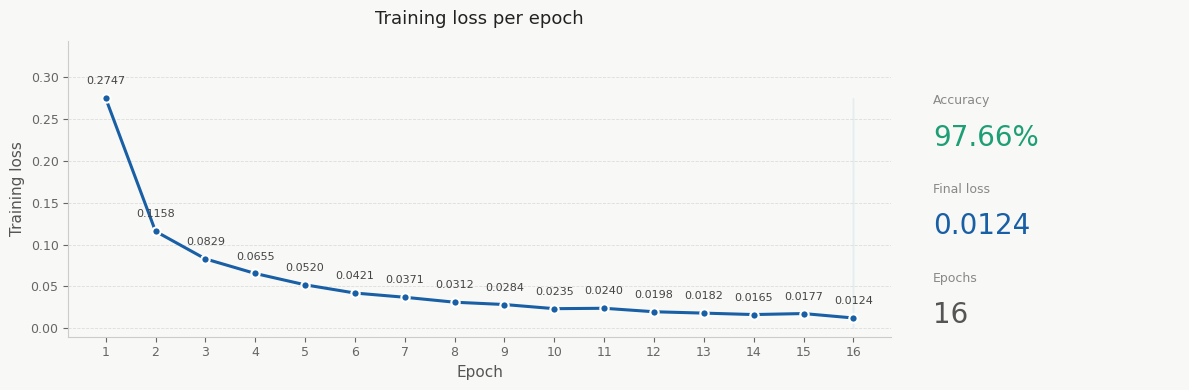

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


epochs_range = range(1, len(epoch_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                         gridspec_kw={'width_ratios': [3, 1]})
fig.patch.set_facecolor('#f8f8f6')

# --- Vänster: loss-kurva ---
ax = axes[0]
ax.set_facecolor('#f8f8f6')
ax.plot(epochs_range, epoch_losses, color='#185FA5', linewidth=2.2,
        marker='o', markersize=6,
        markerfacecolor='#185FA5', markeredgecolor='white', markeredgewidth=1.5,
        zorder=3)
ax.fill_between(epochs, epoch_losses, alpha=0.08, color='#185FA5')

for i, (e, l) in enumerate(zip(epochs_range, epoch_losses)):
    offset = 0.008 if i < len(epochs_range) - 1 else -0.002
    ax.annotate(f'{l:.4f}', xy=(e, l), xytext=(0, 10),
                textcoords='offset points', ha='center',
                fontsize=8, color='#444', zorder=4)

ax.set_xlabel('Epoch', fontsize=11, color='#555')
ax.set_ylabel('Training loss', fontsize=11, color='#555')
ax.set_title('Training loss per epoch', fontsize=13, fontweight='medium', color='#222', pad=12)
ax.set_xticks(epochs_range)
ax.set_ylim(-0.01, max(epoch_losses) * 1.25)
ax.tick_params(colors='#666', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#ccc')
ax.grid(axis='y', color='#ddd', linewidth=0.6, linestyle='--')

# --- Höger: sammanfattning ---
ax2 = axes[1]
ax2.set_facecolor('#f8f8f6')
ax2.axis('off')

metrics = [
    ('Accuracy',    f'{final_acc:.2f}%', '#1D9E75'),
    ('Final loss',  f'{epoch_losses[-1]:.4f}', '#185FA5'),
    ('Epochs',      str(len(epochs_range)),    '#555555'),
]
for idx, (label, value, color) in enumerate(metrics):
    y = 0.82 - idx * 0.30
    ax2.text(0.1, y,      label, transform=ax2.transAxes,
             fontsize=9, color='#888', va='top')
    ax2.text(0.1, y-0.10, value, transform=ax2.transAxes,
             fontsize=20, fontweight='medium', color=color, va='top')

plt.tight_layout()
plt.show()

## (D) ✅ Samma som (C), men exekverad på en CUDA GPU

- Om du kört på GPU redan i uppgift C, så har du automatiskt klarat av både C & D.
- GPU:n behöver stöda CUDA v11.6 eller högre, vilket motsvarar en GPU från NVIDIA’s Pascal-generation eller senare (Exempel på Pascal-kort: GeForce GTX-1080, Quadro P5000, Tesla P100). (Senare generationer: Volta, Turing, Ampère, Ada, Hopper, Blackwell).
- Google Colab har billiga/gratis notebook-instanser med NVIDIA T4 GPU, vilket är en enkel type av Turing-GPU. Denna fungerar utmärkt för uppgiften, men har du en modern NVIDIA-GPU i din dator är den troligen snabbare än en T4.
- Tips kring att använda GPU för beräkningarna:

In [12]:
import torch

print(f"PyTorch version: {torch.__version__}")

if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Number of GPUs available: {num_gpus}")
    for i in range(num_gpus):
        print(f"GPU {i + 1}: {torch.cuda.get_device_name(i)}")
else:
    print("CUDA is not available.")

PyTorch version: 2.11.0+cu128
Number of GPUs available: 1
GPU 1: NVIDIA GeForce RTX 3090


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Hyperparametrar
batch_size = 64


# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Ladda dataset
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_loader

In [14]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Använder: {device}")

Använder: cuda


In [16]:
learning_rate = 0.001
epochs = 16
epoch_losses = []

model = SimpleNN().to(device)

# Loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Träningsloop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_losses.append(total_loss / len(train_loader))

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/16, Loss: 0.2658
Epoch 2/16, Loss: 0.1111
Epoch 3/16, Loss: 0.0782
Epoch 4/16, Loss: 0.0609
Epoch 5/16, Loss: 0.0508
Epoch 6/16, Loss: 0.0401
Epoch 7/16, Loss: 0.0344
Epoch 8/16, Loss: 0.0308
Epoch 9/16, Loss: 0.0271
Epoch 10/16, Loss: 0.0223
Epoch 11/16, Loss: 0.0212
Epoch 12/16, Loss: 0.0182
Epoch 13/16, Loss: 0.0180
Epoch 14/16, Loss: 0.0188
Epoch 15/16, Loss: 0.0161
Epoch 16/16, Loss: 0.0135


In [17]:
# Utvärdering
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)

        total += target.size(0)
        correct += (predicted == target).sum().item()

final_acc = 100 * correct / total
print(f"Accuracy: {final_acc:.2f}%")

Accuracy: 98.07%


# Visualisera körningen

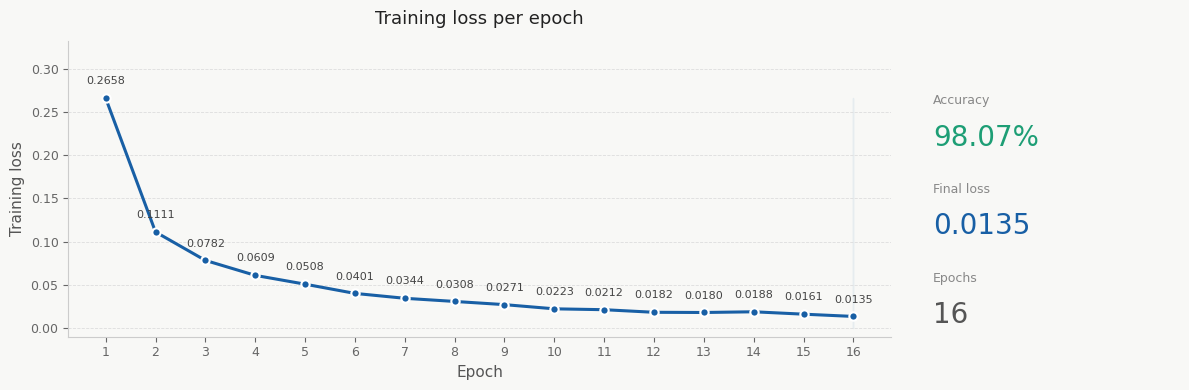

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


epochs_range = range(1, len(epoch_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                         gridspec_kw={'width_ratios': [3, 1]})
fig.patch.set_facecolor('#f8f8f6')

# --- Vänster: loss-kurva ---
ax = axes[0]
ax.set_facecolor('#f8f8f6')
ax.plot(epochs_range, epoch_losses, color='#185FA5', linewidth=2.2,
        marker='o', markersize=6,
        markerfacecolor='#185FA5', markeredgecolor='white', markeredgewidth=1.5,
        zorder=3)
ax.fill_between(epochs, epoch_losses, alpha=0.08, color='#185FA5')

for i, (e, l) in enumerate(zip(epochs_range, epoch_losses)):
    offset = 0.008 if i < len(epochs_range) - 1 else -0.002
    ax.annotate(f'{l:.4f}', xy=(e, l), xytext=(0, 10),
                textcoords='offset points', ha='center',
                fontsize=8, color='#444', zorder=4)

ax.set_xlabel('Epoch', fontsize=11, color='#555')
ax.set_ylabel('Training loss', fontsize=11, color='#555')
ax.set_title('Training loss per epoch', fontsize=13, fontweight='medium', color='#222', pad=12)
ax.set_xticks(epochs_range)
ax.set_ylim(-0.01, max(epoch_losses) * 1.25)
ax.tick_params(colors='#666', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#ccc')
ax.grid(axis='y', color='#ddd', linewidth=0.6, linestyle='--')

# --- Höger: sammanfattning ---
ax2 = axes[1]
ax2.set_facecolor('#f8f8f6')
ax2.axis('off')

metrics = [
    ('Accuracy',    f'{final_acc:.2f}%', '#1D9E75'),
    ('Final loss',  f'{epoch_losses[-1]:.4f}', '#185FA5'),
    ('Epochs',      str(len(epochs_range)),    '#555555'),
]
for idx, (label, value, color) in enumerate(metrics):
    y = 0.82 - idx * 0.30
    ax2.text(0.1, y,      label, transform=ax2.transAxes,
             fontsize=9, color='#888', va='top')
    ax2.text(0.1, y-0.10, value, transform=ax2.transAxes,
             fontsize=20, fontweight='medium', color=color, va='top')

plt.tight_layout()
plt.show()